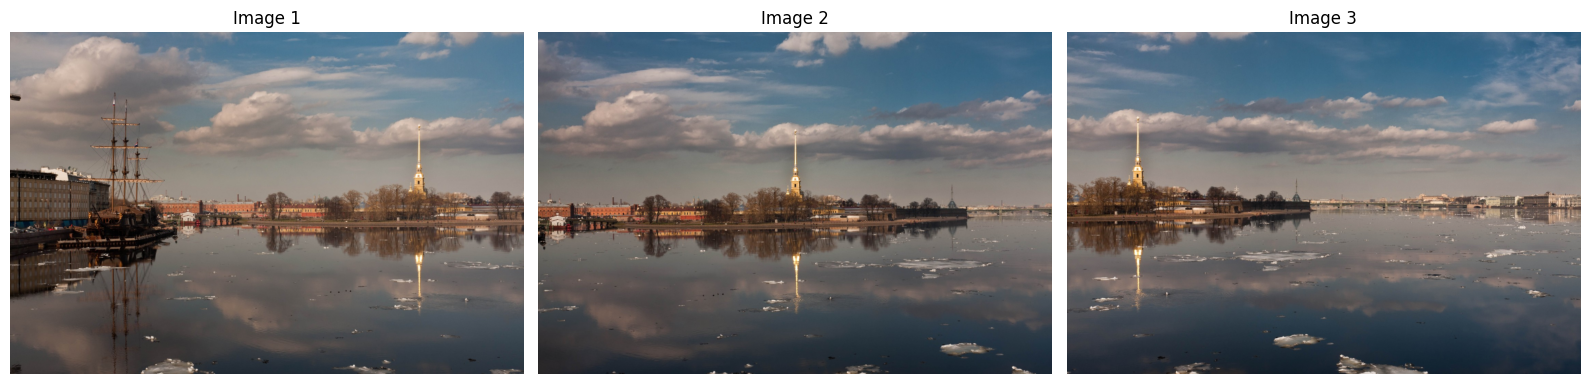

Keypoints: 1875
Keypoints: 1330
Keypoints: 1302
Image 1 -> 2 : good matches = 530  inliers = 501
Image 3 -> 2 : good matches = 445  inliers = 359


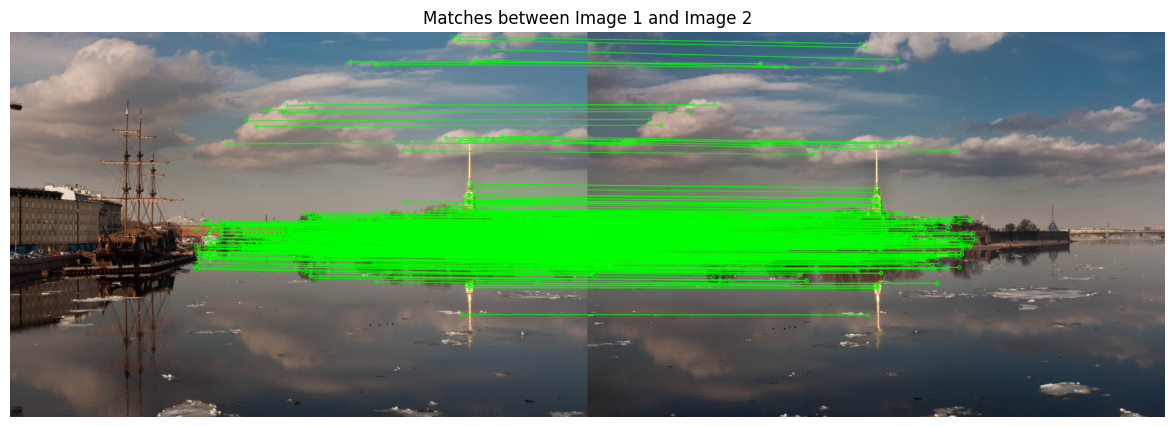

Panorama size: 1909 x 811


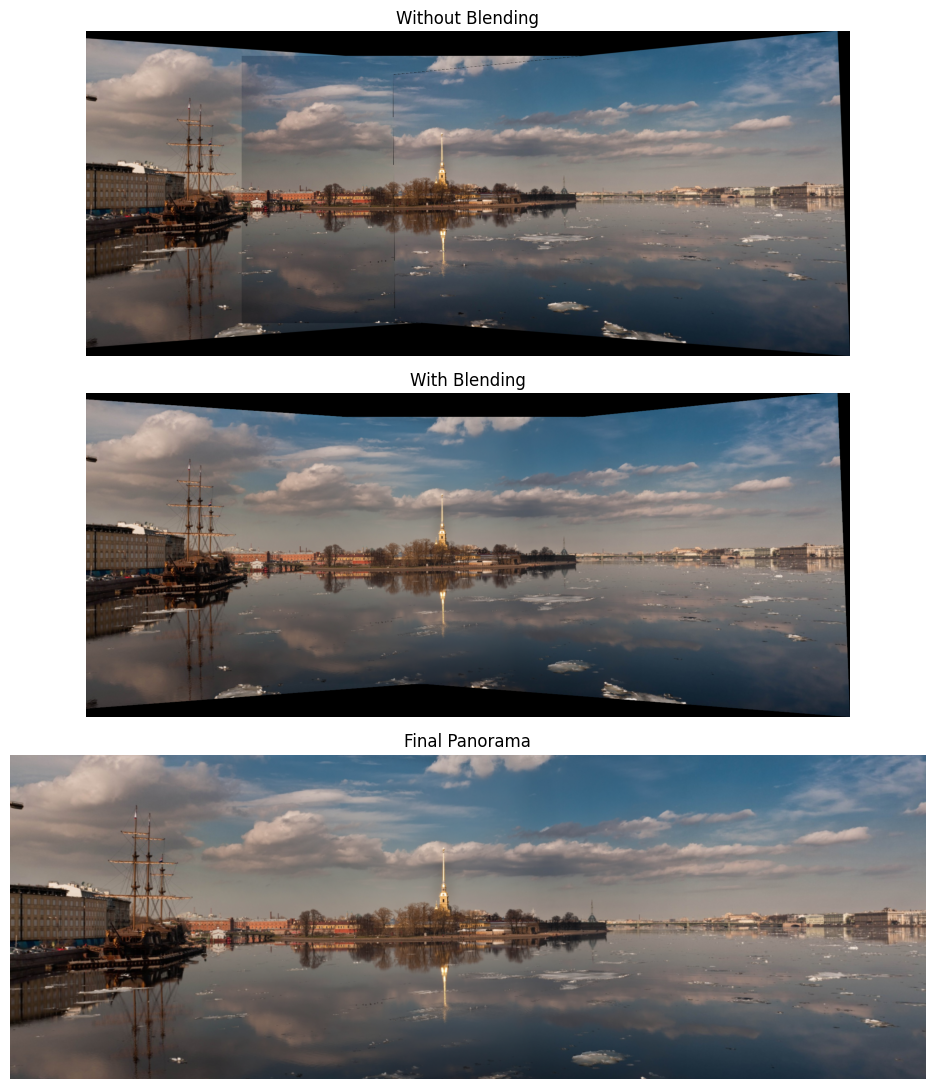

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the 3 images (left, middle, right)
img1 = cv2.imread("boat1.jpg")
img2 = cv2.imread("boat2.jpg")
img3 = cv2.imread("boat3.jpg")
if img1 is None or img2 is None or img3 is None:
    print("Image not found, check the path")

# Resize so it runs faster
img1 = cv2.resize(img1, (1000, 667))
img2 = cv2.resize(img2, (1000, 667))
img3 = cv2.resize(img3, (1000, 667))
images = [img1, img2, img3]

plt.figure(figsize=(16, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title("Image " + str(i + 1))
    plt.axis("off")
plt.tight_layout()
plt.show()

# Create SIFT detector
sift = cv2.SIFT_create()

# Keypoints and descriptors for each image
keypoints = []
descriptors = []
for img in images:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kp, des = sift.detectAndCompute(gray, None)
    keypoints.append(kp)
    descriptors.append(des)
    print("Keypoints:", len(kp))

# Brute force matcher
bf = cv2.BFMatcher()

# function to find homography from image a to image b
def get_homography(a, b):
    matches = bf.knnMatch(descriptors[a], descriptors[b], k=2)

    # Lowe's ratio test
    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    src_pts = np.float32([keypoints[a][m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([keypoints[b][m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    # Homography with RANSAC
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 4.0)
    print("Image", a + 1, "->", b + 1, ": good matches =", len(good), " inliers =", int(mask.sum()))
    return H, good, mask

# middle image is the base, so map image 1 and image 3 onto image 2
H1, good1, mask1 = get_homography(0, 1)
H3, good3, mask3 = get_homography(2, 1)
H2 = np.eye(3)
H_list = [H1, H2, H3]

# Show matches between image 1 and image 2
match_image = cv2.drawMatches(img1, keypoints[0], img2, keypoints[1], good1, None,
                              matchColor=(0, 255, 0), matchesMask=mask1.ravel().tolist(), flags=2)
plt.figure(figsize=(16, 5))
plt.imshow(cv2.cvtColor(match_image, cv2.COLOR_BGR2RGB))
plt.title("Matches between Image 1 and Image 2")
plt.axis("off")
plt.show()

# Find size of the final panorama
# move the corners of every image and see where they go
all_corners = []
for i in range(3):
    h, w = images[i].shape[:2]
    corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
    moved = cv2.perspectiveTransform(corners, H_list[i])
    all_corners.append(moved)
all_corners = np.concatenate(all_corners)

x_min, y_min = np.int32(all_corners.min(axis=0).ravel())
x_max, y_max = np.int32(all_corners.max(axis=0).ravel())

# shift everything so nothing goes outside (negative)
T = np.array([[1, 0, -x_min], [0, 1, -y_min], [0, 0, 1]], dtype=float)
pano_w = x_max - x_min
pano_h = y_max - y_min
print("Panorama size:", pano_w, "x", pano_h)

# Warp every image onto the panorama
warped = []
weights = []
for i in range(3):
    img_warp = cv2.warpPerspective(images[i], T @ H_list[i], (pano_w, pano_h))
    mask = cv2.warpPerspective(np.ones(images[i].shape[:2], np.uint8), T @ H_list[i], (pano_w, pano_h))
    # weight is high at center and low at edges, so joins look smooth
    weight = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    warped.append(img_warp.astype(np.float32))
    weights.append(weight)

# Simple stitching (just paste one over the other)
simple = np.zeros((pano_h, pano_w, 3), np.uint8)
for img_warp in warped:
    filled = img_warp.sum(axis=2) > 0
    simple[filled] = img_warp[filled].astype(np.uint8)

# Blending (weighted average in overlap areas)
total_weight = weights[0] + weights[1] + weights[2]
total_weight[total_weight == 0] = 1
panorama = np.zeros((pano_h, pano_w, 3), np.float32)
for i in range(3):
    panorama += warped[i] * weights[i][:, :, None]
panorama = panorama / total_weight[:, :, None]
panorama = panorama.astype(np.uint8)

# Crop the black borders
filled = (weights[0] + weights[1] + weights[2]) > 0
rows = np.where(filled.mean(axis=1) > 0.98)[0]
cols = np.where(filled[rows[0]:rows[-1]].mean(axis=0) > 0.98)[0]
final = panorama[rows[0]:rows[-1], cols[0]:cols[-1]]
cv2.imwrite("panorama.jpg", final)

plt.figure(figsize=(18, 11))

plt.subplot(3, 1, 1)
plt.imshow(cv2.cvtColor(simple, cv2.COLOR_BGR2RGB))
plt.title("Without Blending")
plt.axis("off")

plt.subplot(3, 1, 2)
plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
plt.title("With Blending")
plt.axis("off")

plt.subplot(3, 1, 3)
plt.imshow(cv2.cvtColor(final, cv2.COLOR_BGR2RGB))
plt.title("Final Panorama")
plt.axis("off")

plt.tight_layout()
plt.show()